## EDA - Exploratory Data Analysis

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [7]:
conexao = sqlite3.connect("../credito.db")
df = pd.read_sql_query("SELECT * FROM clientes", conexao)
conexao.close()

df.head()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0


## Distribuição da variável alvo (SeriousDlqin2yrs)
Visualizando em gráfico de barras a proporção de clientes inadimplentes vs não inadimplentes, 
para confirmar visualmente o desbalanceamento identificado na Semana 1 (93,4% vs 6,6%).

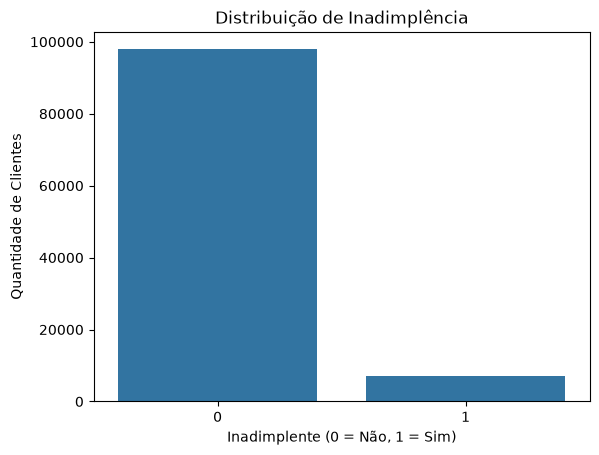

In [8]:
#função do seaborn que conta quantas linhas existem para cada valor de uma coluna e já desenha isso como gráfico de barras, automaticamente

sns.countplot(data=df, x="SeriousDlqin2yrs")
plt.title("Distribuição de Inadimplência")
plt.xlabel("Inadimplente (0 = Não, 1 = Sim)") 
plt.ylabel("Quantidade de Clientes")
plt.show()

## Distribuição de idade
Visualizando a distribuição de idade dos clientes com um histograma, para confirmar visualmente os outliers identificados na Semana 1 (idade mínima 0 e máxima 109) e observar o formato geral da distribuição.

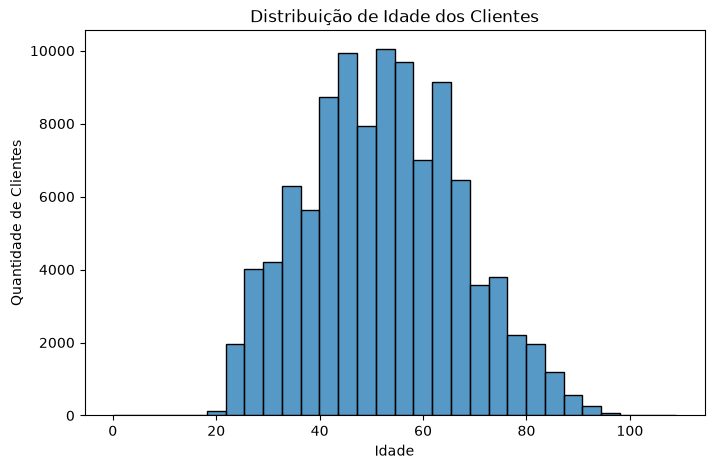

In [9]:
plt.figure(figsize=(8, 5))                      #cria uma "área de desenho" nova antes do gráfico, definindo o tamanho em polegadas
sns.histplot(data=df, x="age", bins=30)         #bins controla quantas barras aparecem no gráfico
plt.title("Distribuição de Idade dos Clientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade de Clientes")
plt.show()

## Outliers em RevolvingUtilizationOfUnsecuredLines e DebtRatio
Visualizando com boxplot os valores extremos identificados na Semana 1, 
que deveriam ser proporções (0 a 1) mas apresentam valores muito acima disso.

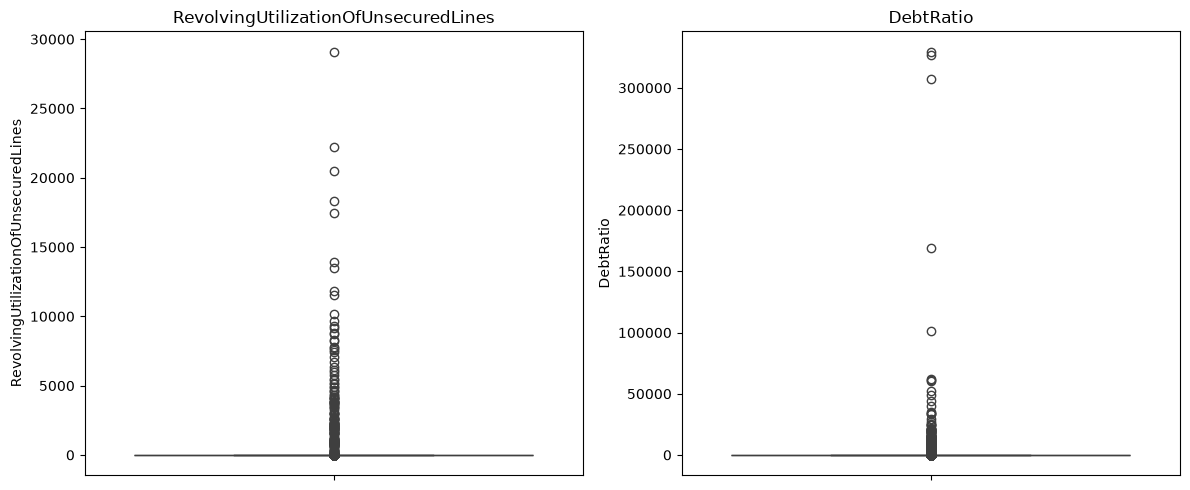

In [10]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))  #subplot cria grade de gráficos lado a lado/ 1 linha e 2 colunas

sns.boxplot(data=df, y="RevolvingUtilizationOfUnsecuredLines", ax=eixos[0])  #Esq
eixos[0].set_title("RevolvingUtilizationOfUnsecuredLines")

sns.boxplot(data=df, y="DebtRatio", ax=eixos[1])   #Dir
eixos[1].set_title("DebtRatio")

plt.tight_layout()
plt.show()


# Necessidade de tratar futuramente

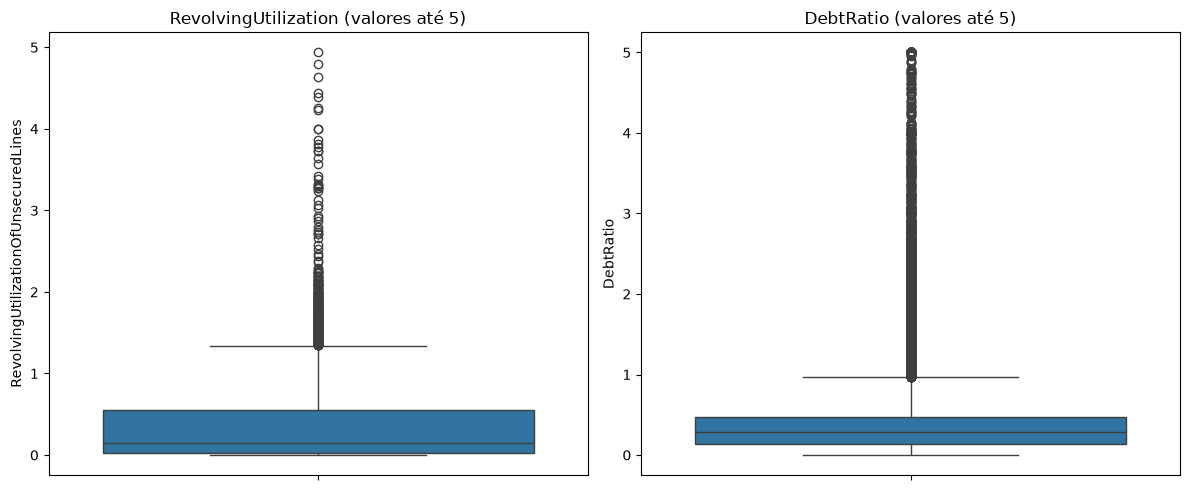

In [11]:
# Análise individual

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df[df["RevolvingUtilizationOfUnsecuredLines"] <= 5], y="RevolvingUtilizationOfUnsecuredLines", ax=eixos[0])
eixos[0].set_title("RevolvingUtilization (valores até 5)")

sns.boxplot(data=df[df["DebtRatio"] <= 5], y="DebtRatio", ax=eixos[1])
eixos[1].set_title("DebtRatio (valores até 5)")

plt.tight_layout()
plt.show()

# retangulo azul = maioria dos dados

#A linha dentro da caixa: é a mediana (o valor do meio de tudo, mesma ideia que calculamos em SQL pra renda).
#As "linhas" saindo da caixa (os "bigodes"): mostram até onde os dados "normais" se estendem, pra cima e pra baixo, antes de virarem outliers.
#Os pontinhos isolados acima do bigode superior: são os outliers — valores considerados estatisticamente "fora do padrão" comparado com o resto.

A caixa azul é bem baixinha, ficando entre aproximadamente 0 e 0,6 —          |  A caixa azul vai de aproximadamente 0,2 até quase 0,6
confirma que a maioria dos clientes usa uma fração pequena do                 |  a mediana parece estar perto de 0,35-0,4.
limite de crédito disponível,                                                 |
o que faz sentido (a maioria das pessoas não estoura o cartão).               |

## Hipótese: DebtRatio anômalo está relacionado a MonthlyIncome nulo
Comparando a distribuição de DebtRatio entre clientes com renda informada e clientes com renda nula, para investigar se o problema de escala está concentrado num desses grupos.

In [12]:
df["renda_informada"] = df["MonthlyIncome"].notnull() # cria uma coluna onde lista  verdadeiro ou falso, informando rendas informadas ou não

resumo = df.groupby("renda_informada")["DebtRatio"].describe() 
#agrupa por renda informada e não informada e depois dizemos qual coluna queremos olhar especificamente(indice de endividamento)
print(resumo)

#Count, Média, Desvio padrão(variação da média),

                   count         mean          std  min         25%  \
renda_informada                                                       
False            20781.0  1679.689524  4548.284936  0.0  124.000000   
True             84024.0    27.199594   459.893908  0.0    0.143427   

                        50%          75%       max  
renda_informada                                     
False            1164.00000  2391.000000  329664.0  
True                0.29611     0.482986   61106.5  


DebtRatio fica errado (valores absurdos) justamente quando MonthlyIncome (Renda) é nula — 
o sistema parece ter deixado o valor das despesas "cru" em vez de dividir pela renda. Precisa tratar esse grupo separado do resto.

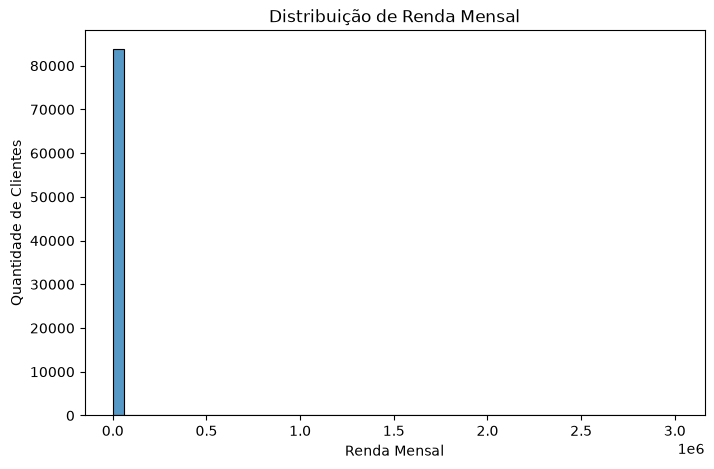

In [13]:
## Distribuição de MonthlyIncome
#Visualizando a distribuição de renda mensal (apenas clientes com renda informada), 
#para confirmar visualmente a assimetria já identificada em SQL (média R$ 6.684 vs mediana R$ 5.400) e observar se existem outliers extremos.

plt.figure(figsize=(8, 5))
sns.histplot(data=df[df["renda_informada"] == True], x="MonthlyIncome", bins=50)
plt.title("Distribuição de Renda Mensal")
plt.xlabel("Renda Mensal")
plt.ylabel("Quantidade de Clientes")
plt.show()

In [14]:
df[df["renda_informada"] == True]["MonthlyIncome"].max()

np.float64(3008750.0)

## Distribuição de MonthlyIncome (com filtro de outliers)
Refazendo o histograma limitando a valores até R$ 20.000, já que o máximo real (R$ 3.008.750) distorcia o gráfico anterior.

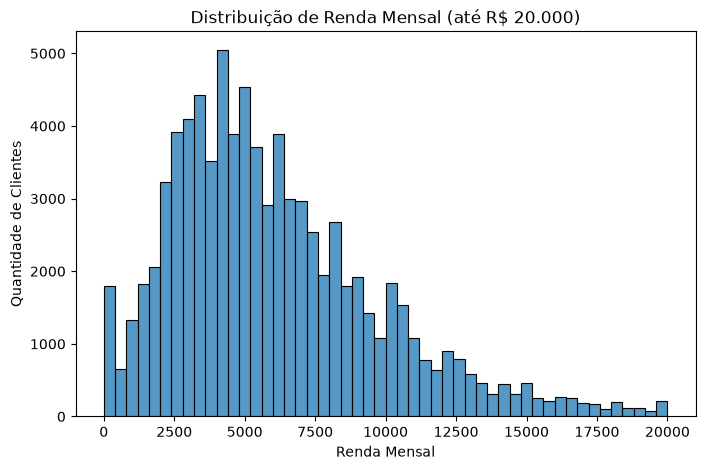

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df[(df["renda_informada"] == True) & (df["MonthlyIncome"] <= 20000)], x="MonthlyIncome", bins=50)
plt.title("Distribuição de Renda Mensal (até R$ 20.000)")
plt.xlabel("Renda Mensal")
plt.ylabel("Quantidade de Clientes")
plt.show()

## Matriz de correlação
Visualizando a correlação entre todas as variáveis numéricas, incluindo a variável alvo, para identificar rapidamente quais features têm relação mais forte com a inadimplência e se existe redundância entre variáveis (multicolinearidade).

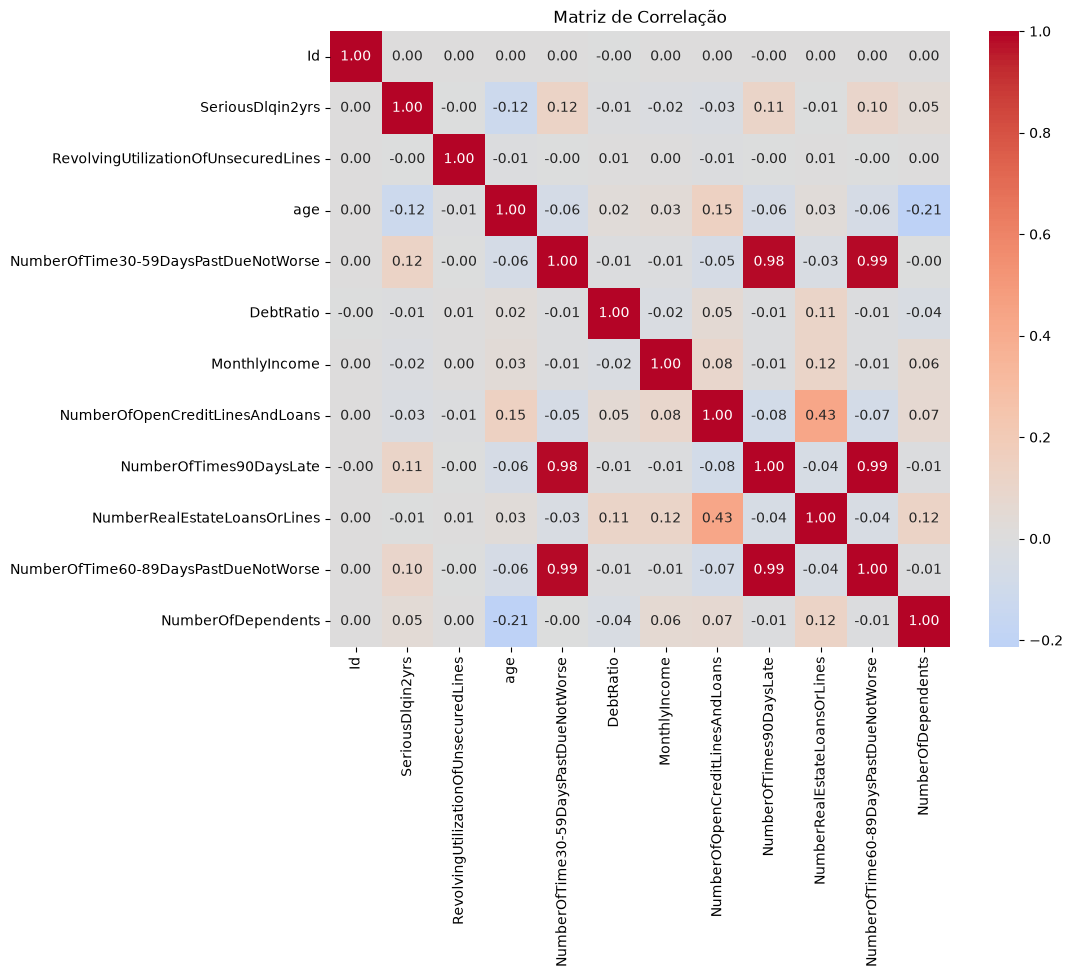

In [16]:
plt.figure(figsize=(10, 8))
correlacoes = df.drop(columns=["renda_informada"]).corr()
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()

Multicolinearidade forte: as 3 variáveis de atraso (30-59, 60-89, 90+ dias) são quase a mesma coisa (correlação de 0,98-0,99 entre si).
Correlação com o alvo é fraca em geral (máximo 0,12, com age) — porque correlação mede relação linear, 
e os padrões fortes que vimos em SQL (ex: 4,6% → 41,6%) são não lineares, então aparecem "escondidos" aqui.
Id não correlaciona com nada, confirmando que é só índice, sem valor analítico.

In [ ]:
#Revisão pra tratar:

#Coluna Id — sem valor analítico, descartar
#age = 0 — 1 registro, erro de dado, descartar
#MonthlyIncome nulo (~20% da base) — precisa de decisão de imputação
#MonthlyIncome com outliers extremos (ex: R$ 3 milhões) — precisa de tratamento
#DebtRatio corrompido quando renda é nula — precisa de tratamento específico
#RevolvingUtilizationOfUnsecuredLines com outliers (243 registros acima de 2)

#Começando pelo mais simples: remover a coluna Id e o registro com age = 0.

## Tratamento 1: remover coluna Id e registro com idade inválida
Removendo a coluna de índice (sem valor analítico) e o único registro com age = 0, identificado como erro de dado na Semana 1.

In [17]:
df = df.drop(columns=["Id"])
df = df[df["age"] > 0]

print(df.shape)

(104804, 12)


In [18]:
#confirmar nome da coluna (id)
df.columns.tolist()

['SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'renda_informada']

In [ ]:
#"identificamos que o tratamento previsto não era mais necessário, pois a exportação anterior já eliminava a coluna" index=false na semana 1)

Tratamento de MonthlyIncome : os ~20% de valores nulos e os outliers extremos (como aquele registro de R$ 3 milhões).

## Tratamento 2: MonthlyIncome — nulos e outliers
Nulos preenchidos com a mediana da faixa etária correspondente (renda varia com idade, como visto na Semana 1). Outliers extremos (ex: R$ 3 milhões) tratados com teto no percentil 99, valor definido pelos próprios dados.

In [ ]:
df["faixa_etaria"] = pd.cut(df["age"], bins=[0, 29, 44, 59, 120], labels=["18-29", "30-44", "45-59", "60+"]) #cria coluna após definir os cortes e nomeia-los

mediana_por_faixa = df.groupby("faixa_etaria")["MonthlyIncome"].transform("median") #cada linha recebe a mediana da sua própria faixa etária, repetida quantas vezes for preciso.
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(mediana_por_faixa)                 #Isso é essencial pra poder combinar com fillna.

teto_renda = df["MonthlyIncome"].quantile(0.99)                 #se você ordenasse todos os clientes do mais pobre pro mais rico, 
                                                                #esse número é onde fica o cliente na posição 99% do caminho — só 1% da base ganha mais que isso.

df["MonthlyIncome"] = df["MonthlyIncome"].clip(upper=teto_renda)# Qualquer valor acima do teto vira exatamente o teto (não remove ninguém, só reduz o número). 
                                                                # Então se o teto for, digamos, R$ 25.000, aquele cliente de R$ 3 milhões passa a valer R$ 25.000 na coluna — 
                                                                # ele continua na base, só que sem distorcer mais os cálculos.

print("Teto aplicado:", teto_renda)
print(df["MonthlyIncome"].isnull().sum()) # Se o tratamento funcionou retorna 0

Teto aplicado: 23266.70000000001
0


C:\Users\ryanp\AppData\Local\Temp\ipykernel_30280\568136055.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mediana_por_faixa = df.groupby("faixa_etaria")["MonthlyIncome"].transform("median")


.transform("median")  Diferente do .mean() ou .describe() (que devolvem um resultado por grupo, tipo uma linha pra "18-29" e outra pra "30-44"), o transform calcula a mediana de cada grupo mas devolve o valor repetido em cada linha original. Ou seja: se você tem 6.105 clientes na faixa "18-29", o transform calcula UMA mediana pra esse grupo, mas devolve essa mesma mediana 6.105 vezes, uma pra cada cliente daquela faixa.

Por que fazer assim, e não do jeito "resumido"? Porque no próximo passo precisamos comparar "linha por linha" com a coluna original de renda — e pra isso, o tamanho das duas listas (a de renda original e a das medianas) precisa ser igual, linha por linha. Se tivéssemos usado .mean() normal, teríamos só 4 valores (um por faixa), impossível de comparar diretamente com as 104.804 linhas do df.

.fillna(mediana_por_faixa) — percorre a coluna MonthlyIncome linha por linha: onde encontra um valor nulo, substitui pelo valor correspondente de mediana_por_faixa (que já sabemos, é a mediana da faixa etária daquele cliente específico, graças ao transform). Onde já tinha um valor preenchido, não mexe em nada.
df["MonthlyIncome"] = ... — sobrescreve a coluna original com essa versão já preenchida.

In [ ]:
#Teto aplicado: R$ 23.266,70 — ou seja, o percentil 99 da sua base. Aquele cliente de R$ 3 milhões (e qualquer outro acima desse valor) 
# agora tem a renda "aparada" pra R$ 23.266,70, sem sair da base.
#0 nulos restantes — os ~20.781 registros sem renda foram todos preenchidos com a mediana da faixa etária correspondente.

## Tratamento 3: DebtRatio — recalculando os casos corrompidos e tratando outliers
Para clientes que tinham renda nula (renda_informada = False), o valor de DebtRatio representava as despesas em valor absoluto,
 não uma proporção. Recalculamos DebtRatio = despesas ÷ nova renda (já imputada), usando o valor bruto original como proxy de despesas.
  Em seguida, aplicamos um teto no percentil 99 para os outliers remanescentes.

In [ ]:
mask_corrompido = df["renda_informada"] == False

df.loc[mask_corrompido, "DebtRatio"] = df.loc[mask_corrompido, "DebtRatio"] / df.loc[mask_corrompido, "MonthlyIncome"]
#permite selecionar e alterar um pedaço específico do DataFrame — só as linhas que batem com mask_corrompido


teto_debtratio = df["DebtRatio"].quantile(0.99)
df["DebtRatio"] = df["DebtRatio"].clip(upper=teto_debtratio)

print("Teto aplicado:", teto_debtratio)
print(df["DebtRatio"].describe())

Teto aplicado: 274.0
count    104804.000000
mean          3.461950
std          28.246984
min           0.000000
25%           0.120169
50%           0.282424
75%           0.473752
max         274.000000
Name: DebtRatio, dtype: float64


In [ ]:
#Resumo: DebtRatio corrigido — recalculado (despesas ÷ nova renda) para quem tinha renda nula, e aplicado teto no percentil 99 (274,0) para outliers.
# Mediana ficou em 0,28, praticamente igual à dos clientes que já tinham renda válida, confirmando que o tratamento funcionou.

## Tratamento 4: RevolvingUtilizationOfUnsecuredLines — outliers
Aplicando teto no percentil 99 para conter os valores extremos (até 29.110), sem uma causa identificada como no DebtRatio.

In [21]:
teto_revolving = df["RevolvingUtilizationOfUnsecuredLines"].quantile(0.99)
df["RevolvingUtilizationOfUnsecuredLines"] = df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=teto_revolving)

print("Teto aplicado:", teto_revolving)
print(df["RevolvingUtilizationOfUnsecuredLines"].describe())

Teto aplicado: 1.08981677814
count    104804.000000
mean          0.320282
std           0.352063
min           0.000000
25%           0.029800
50%           0.153983
75%           0.559153
max           1.089817
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [ ]:
#RevolvingUtilizationOfUnsecuredLines tratado — teto no percentil 99 (1,09), 1,9% estourou levemente o limite (por juros, por exemplo)
#mediana de 0,15 (uso baixo do limite de crédito na maioria).

## Salvando a base tratada
Persistindo o DataFrame tratado (idade, MonthlyIncome, DebtRatio e RevolvingUtilization corrigidos) em uma nova tabela no banco, para reutilizar na Semana 3 sem repetir os tratamentos.

In [22]:
conexao = sqlite3.connect("../credito.db")
df.to_sql("clientes_tratados", conexao, if_exists="replace", index=False)
conexao.close()

print("Tabela salva com sucesso")

Tabela salva com sucesso
